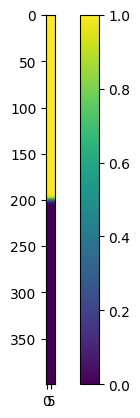

In [105]:
import numpy as np
import h5py
import matplotlib.pyplot as plt


Nx = 10      # Width 
Ny = 400     # Height 
W = 5.0      # Interface thickness

x = np.arange(Nx)
y = np.arange(Ny)
xv, yv = np.meshgrid(y, x) 

phi = 0.5 + 0.5 * np.tanh(2.0 * (0.5 * Ny - xv) / W)
phi = phi.astype(np.float64)

plt.imshow(phi.T)
plt.colorbar()

filename = 'phi_init.h5'
with h5py.File(filename, 'w') as f:
    f.create_dataset('phi_init', data=phi)


Driving force Gx: 2.53e-07
relative error norm: 0.10


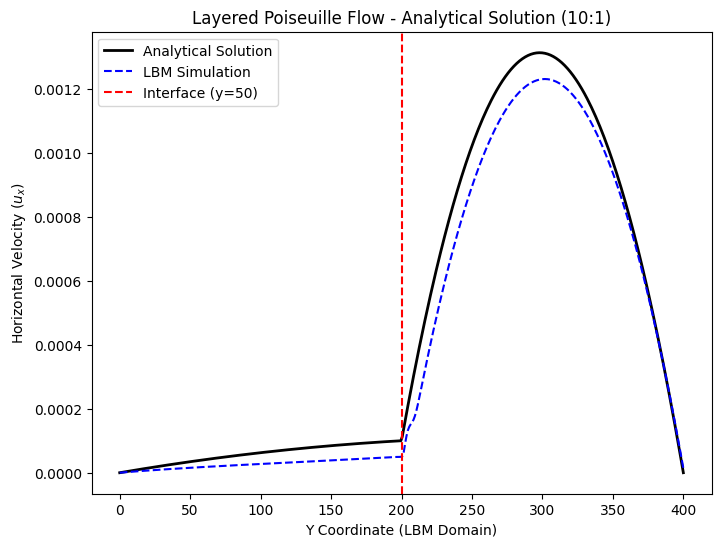

In [107]:
import numpy as np
import matplotlib.pyplot as plt

Ny = 400            # Total height of the domain
h = Ny / 2.0        # Half-channel height
uc = 1e-4           # Target centerline velocity

# Fluid properties (Density ratio 1000:1)
rho_l = 1000.0
rho_g = 1.0
nu_l = 0.1
nu_g = 1.0

# Dynamic viscosities (mu = rho * nu)
mu_l = rho_l * nu_l
mu_g = rho_g * nu_g

# Driving force based on the paper's formula
Gx = uc * (mu_l + mu_g) / (h**2)
print(f"Driving force Gx: {Gx:.2e}")
y_lbm = np.linspace(0, Ny, Ny)
y = y_lbm - h 

#  Analytical Solution (Equation 36) of PHYSICAL REVIEW E 97, 033309 (2018)
ux = np.zeros_like(y)
# Top half: Gas (0 < y <= h)
mask_gas = y > 0
ux[mask_gas] = (Gx * h**2 / (2 * mu_g)) * (
    - (y[mask_gas] / h)**2 
    - (y[mask_gas] / h) * ((mu_g - mu_l) / (mu_g + mu_l)) 
    + (2 * mu_g) / (mu_g + mu_l)
)
# Bottom half: Liquid (-h <= y <= 0)
mask_liquid = y <= 0
ux[mask_liquid] = (Gx * h**2 / (2 * mu_l)) * (
    - (y[mask_liquid] / h)**2 
    - (y[mask_liquid] / h) * ((mu_g - mu_l) / (mu_g + mu_l)) 
    + (2 * mu_l) / (mu_g + mu_l)
)

with h5py.File('layered_poiseuille.h5', 'r') as hf:
    keys = list(hf.keys())
    c_key_idx = np.sort([int(k.split('.')[-1]) for k in keys if 'velocity_x' in k])

    plot_var = hf['velocity_x.'+str(c_key_idx[-1])][()].T


lbm_velocity_profile = plot_var[:, -plot_var.shape[1]//2]
error =np.linalg.norm(ux - lbm_velocity_profile) / np.linalg.norm(ux)
print(f"relative error norm: {error:.2f}")

plt.figure(figsize=(8, 6))
plt.plot(y_lbm, ux, label='Analytical Solution', color='black', linewidth=2)
plt.plot(y_lbm, lbm_velocity_profile, label='LBM Simulation', color='blue', linestyle='--')

plt.ylabel('Error (%)')
plt.axvline(h, color='red', linestyle='--', label='Interface (y=50)')

plt.title('Layered Poiseuille Flow - Analytical Solution (10:1)')
plt.xlabel('Y Coordinate (LBM Domain)')
plt.ylabel('Horizontal Velocity ($u_x$)')
plt.legend()
plt.show()